# WNN Experiments

This notebook implements our Weightless Neural Network.

In [1]:
from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, List, Optional
import hashlib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Load Data

In [2]:
dataPath = Path("Data.csv")


if not dataPath.exists():
    raise FileNotFoundError(f"Data file not found at {dataPath}")

headers = pd.read_csv(dataPath, nrows=0)
cols = headers.columns.tolist()
target_col = "diseases"
symptom_cols = [col for col in cols if col != target_col]
dtype_map = {col: "uint8" for col in symptom_cols}
df = pd.read_csv(dataPath, dtype=dtype_map)

x = df[symptom_cols].to_numpy(dtype=np.float32)
y_cat = df[target_col].astype("category")

class_counts = y_cat.value_counts()
valid_classes = class_counts[class_counts >= 2].index
valid_mask = y_cat.isin(valid_classes)
x = x[valid_mask.to_numpy()]
y_cat = y_cat[valid_mask].astype("category")
y = y_cat.cat.codes.to_numpy(dtype=np.int64)
classes = y_cat.cat.categories.tolist()

TEST_SIZE = 0.15
VAL_SIZE = 0.15

X_train, X_temp, y_train, y_temp = train_test_split(x, y, test_size=TEST_SIZE + VAL_SIZE, random_state=42, stratify=y)
val_share_of_trainval = VAL_SIZE / (TEST_SIZE + VAL_SIZE)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=val_share_of_trainval, random_state=42

)
print(f"Train shape: {X_train.shape}")
print(f"Val shape:   {X_val.shape}")
print(f"Test shape:  {X_test.shape}")
print(f"Num classes: {len(classes)}")




Train shape: (172848, 377)
Val shape:   (37039, 377)
Test shape:  (37039, 377)
Num classes: 773


# Bloom Filter

In [3]:
class BloomFilter:
    def __init__(self, size: int, num_hashes: int):
        self.size = size
        self.num_hashes = num_hashes
        self.bit_array = np.zeros(size, dtype=bool)

    def _hashes(self, item: str) -> List[int]:
        return [int(hashlib.md5((item + str(i)).encode()).hexdigest(), 16) % self.size for i in range(self.num_hashes)]

    def add(self, item: str):
        for hash_val in self._hashes(item):
            self.bit_array[hash_val] = True

    def __contains__(self, item: str) -> bool:
        return all(self.bit_array[hash_val] for hash_val in self._hashes(item))

# WNN Model

In [4]:
class BloomWNN:
    def __init__(self, input_dim: int, num_classes: int, tuple_size: int, filter_size: int, num_hashes: int, seed:int = 42) -> None:
        self.input_dim = input_dim
        self.num_classes = num_classes
        self.tuple_size = tuple_size
        rng = np.random.default_rng(seed)
        perm = rng.permutation(input_dim)
        pad = (-input_dim) % tuple_size
        if pad:
            perm = np.concatenate([perm, np.full(pad, -1, dtype=np.intp)])
        
        self.groups:np.ndarray = perm.reshape(-1, tuple_size)
        self.num_rams: int = len(self.groups)
        self.filters: List[List[BloomFilter]] = [[BloomFilter(filter_size, num_hashes) for _ in range(self.num_rams)] for _ in range(self.num_classes)]

    def tuple_value(self, x: np.ndarray, group: np.ndarray) -> int:
        val = 0
        for bitIdx in group:
            bit = int(x[bitIdx]) if bitIdx >= 0 else 0
            val = (val << 1) | bit
        return val

    def train(self, X:np.ndarray, y: np.ndarray)-> None:
        xBin = (X > 0).astype(int)
        i = 0
        for x, label in zip(xBin, y):
            if i % 10000 == 0:
                print(f"Processed {i} samples")
                i = i+1
            for ram_idx, group in enumerate(self.groups):
                self.filters[int(label)][ram_idx].add(str(self.tuple_value(x, group)))
    
    def scores(self, X: np.ndarray, bleach: int = 1) -> np.ndarray:
        addrs = self._compute_addresses(X)
        n = addrs.shape[0]
        scores = np.zeros((n, self.num_classes), dtype=np.float32)
        ram_indices = np.arange(self.num_rams)
        for cls in range(self.num_classes):
            # Only count RAM addresses seen >= bleach times
            scores[:, cls] = (self.memory[cls, ram_indices[None, :], addrs] >= bleach).sum(axis=1)
        return scores / self.num_rams
    
    def predict(self, X:np.ndarray) -> np.ndarray:
        xBin = (X > 0).astype(int)
        return np.array([np.argmax(self.scores(x)) for x in xBin])

In [5]:
import numpy as np
from dataclasses import dataclass
from typing import Dict, List
from sklearn.metrics import accuracy_score, precision_score


class FastWiSARD:
    """
    Faster WiSARD-style Weightless Neural Network for binary symptom vectors.
    Stores counts of RAM addresses per class.
    """

    def __init__(self, input_dim: int, num_classes: int, tuple_size: int = 8, seed: int = 42):
        self.input_dim = input_dim
        self.num_classes = num_classes
        self.tuple_size = tuple_size

        rng = np.random.default_rng(seed)
        perm = rng.permutation(input_dim)

        pad = (-input_dim) % tuple_size
        self.pad = pad
        if pad > 0:
            perm = np.concatenate([perm, np.full(pad, -1, dtype=np.int32)])

        self.groups = perm.reshape(-1, tuple_size)
        self.num_rams = self.groups.shape[0]
        self.addr_space = 1 << tuple_size  # 2^tuple_size

        # Dense RAM memory: [class, ram, address]
        # uint16 is enough unless the same class/address repeats > 65535 times
        self.memory = np.zeros((num_classes, self.num_rams, self.addr_space), dtype=np.uint16)

        # Bit weights for converting each tuple of 0/1 bits into an integer address
        self.bit_weights = (1 << np.arange(tuple_size - 1, -1, -1, dtype=np.uint32))

        # Replace -1 padding positions with an index to a zero-filled column
        self.index_groups = self.groups.copy()
        self.pad_index = input_dim
        self.index_groups[self.index_groups < 0] = self.pad_index

    def _compute_addresses(self, X: np.ndarray) -> np.ndarray:
        """
        Convert each sample into RAM addresses.
        Output shape: [num_samples, num_rams]
        """
        Xb = (X > 0).astype(np.uint8, copy=False)

        # Add one zero column so padded positions always read as 0
        Xpad = np.concatenate(
            [Xb, np.zeros((Xb.shape[0], 1), dtype=np.uint8)],
            axis=1
        )

        # Gather bits for each RAM group
        # Shape: [num_samples, num_rams, tuple_size]
        gathered = Xpad[:, self.index_groups]

        # Convert tuple of bits to integer RAM address
        addrs = (gathered * self.bit_weights).sum(axis=2, dtype=np.uint32)
        return addrs

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        addrs = self._compute_addresses(X)

        # Fill count tables class by class, RAM by RAM
        for cls in range(self.num_classes):
            cls_mask = (y == cls)
            cls_addrs = addrs[cls_mask]   # [n_cls, num_rams]

            if cls_addrs.shape[0] == 0:
                continue

            for ram_idx in range(self.num_rams):
                counts = np.bincount(cls_addrs[:, ram_idx], minlength=self.addr_space)
                self.memory[cls, ram_idx, :] = counts.astype(np.uint16)

    def scores(self, X: np.ndarray, bleach: int = 1) -> np.ndarray:
        """
        Returns score matrix of shape [num_samples, num_classes].
        Bleach: only count RAMs with activation count >= bleach
        """
        addrs = self._compute_addresses(X)
        n = addrs.shape[0]
        scores = np.zeros((n, self.num_classes), dtype=np.float32)

        ram_indices = np.arange(self.num_rams)

        for cls in range(self.num_classes):
            # self.memory[cls] has shape [num_rams, addr_space]
            # We gather one address per RAM per sample, then sum across RAMs
            activations = self.memory[cls, ram_indices[None, :], addrs]
            # Count only RAMs with activation >= bleach threshold
            scores[:, cls] = (activations >= bleach).sum(axis=1)

        # Don't normalize - let raw count differences matter
        return scores

    def predict(self, X: np.ndarray, bleach: int = 1) -> np.ndarray:
        scores = self.scores(X, bleach=bleach)
        return np.argmax(scores, axis=1)

# Experiment Config

In [6]:
@dataclass
class WNNConfig:
    name: str
    tuple_size: int
    filter_size: int
    num_hashes: int
    seed: int = 42

WNN_Experiments = [
    WNNConfig(name="WNN t=8", tuple_size=8, filter_size=256, num_hashes=2),
    WNNConfig(name="WNN t=10", tuple_size=10, filter_size=1024, num_hashes=2),
    WNNConfig(name="WNN t=12", tuple_size=12, filter_size=4096, num_hashes=3),
]

def evaluate_model(model, X: np.ndarray, y: np.ndarray, bleach: int = 1) -> Dict[str, float]:
    start = time.perf_counter()
    preds = model.predict(X, bleach=bleach)
    end = time.perf_counter()

    return {
        "accuracy": float(accuracy_score(y, preds)),
        "macro_precision": float(precision_score(y, preds, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(y, preds, average="macro", zero_division=0)),
        "macro_f1": float(f1_score(y, preds, average="macro", zero_division=0)),
        "inference_time_sec": end - start,
        "avg_time_per_sample_ms": 1000.0 * (end - start) / len(X),
        "preds": preds,
    }


def trainWNNExperiment(
    config: WNNConfig,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    classes: List[str],
) -> Dict[str, object]:

    model = FastWiSARD(
        input_dim=X_train.shape[1],
        num_classes=len(classes),
        tuple_size=config.tuple_size,
        seed=config.seed
    )

    train_start = time.perf_counter()
    model.fit(X_train, y_train)
    train_end = time.perf_counter()

    # Try bleach=1 (more sensitive) and bleach=2 (stricter)
    # Choose the one that performs better on val set
    val_metrics_b1 = evaluate_model(model, X_val, y_val, bleach=1)
    val_metrics_b2 = evaluate_model(model, X_val, y_val, bleach=2)
    
    bleach = 1 if val_metrics_b1["accuracy"] >= val_metrics_b2["accuracy"] else 2
    val_metrics = val_metrics_b1 if bleach == 1 else val_metrics_b2
    
    test_metrics = evaluate_model(model, X_test, y_test, bleach=bleach)

    return {
        "config": config,
        "model": model,
        "num_rams": model.num_rams,
        "address_space": model.addr_space,
        "memory_mb": model.memory.nbytes / (1024 ** 2),
        "train_time_sec": train_end - train_start,
        "bleach": bleach,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
    }

# Run Code

Running WNN t=8 ...
Running WNN t=10 ...
Running WNN t=12 ...


,name,tuple_size,num_rams,address_space,memory_mb,train_time_sec,bleach,val_accuracy,val_macro_precision,val_macro_recall,val_macro_f1,val_inference_time_sec,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_inference_time_sec,test_avg_time_per_sample_ms
0,WNN t=10,10,38,1024,57.371094,1.008731,1,0.837550,0.840636,0.794940,0.799179,5.582415,0.832744,0.849789,0.798590,0.804859,5.953626,0.160739
1,WNN t=12,12,32,4096,193.250000,1.073292,1,0.837550,0.841104,0.796312,0.799869,5.209302,0.832744,0.849966,0.798899,0.805153,4.517183,0.121957
2,WNN t=8,8,48,256,18.117188,0.907651,1,0.837496,0.840279,0.794857,0.798915,7.205807,0.832798,0.849838,0.799160,0.805212,6.837318,0.184598


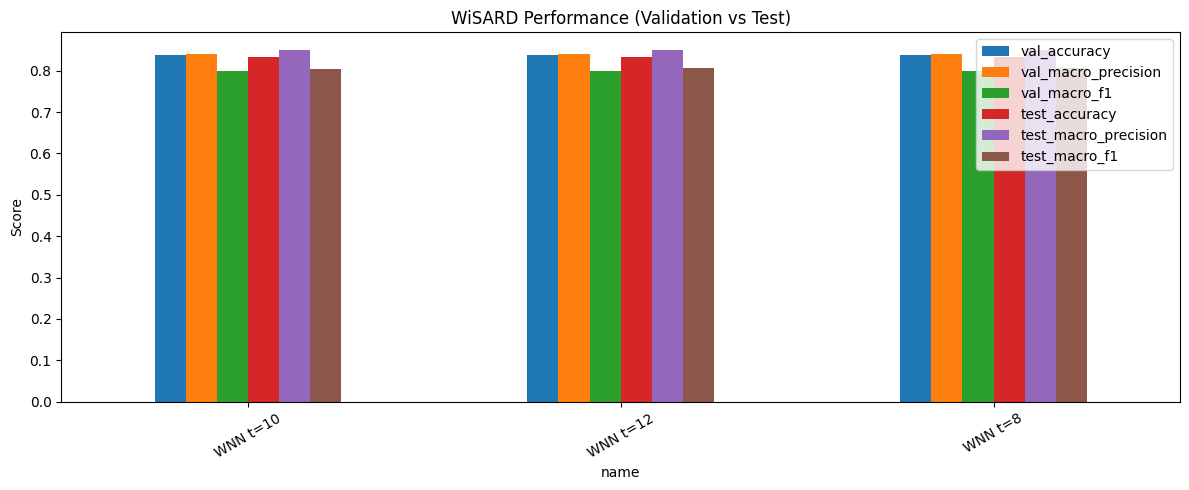

In [7]:
import time
import pandas as pd
import matplotlib.pyplot as plt

rows = []

for cfg in WNN_Experiments:
    print(f"Running {cfg.name} ...")

    result = trainWNNExperiment(
        cfg,
        X_train, y_train,
        X_val, y_val,
        X_test, y_test,
        classes
    )

    rows.append({
        "name": cfg.name,
        "tuple_size": cfg.tuple_size,
        "num_rams": result["num_rams"],
        "address_space": result["address_space"],
        "memory_mb": result["memory_mb"],
        "train_time_sec": result["train_time_sec"],
        "bleach": result["bleach"],

        "val_accuracy": result["val_metrics"]["accuracy"],
        "val_macro_precision": result["val_metrics"]["macro_precision"],
        "val_macro_recall": result["val_metrics"]["macro_recall"],
        "val_macro_f1": result["val_metrics"]["macro_f1"],
        "val_inference_time_sec": result["val_metrics"]["inference_time_sec"],

        "test_accuracy": result["test_metrics"]["accuracy"],
        "test_macro_precision": result["test_metrics"]["macro_precision"],
        "test_macro_recall": result["test_metrics"]["macro_recall"],
        "test_macro_f1": result["test_metrics"]["macro_f1"],
        "test_inference_time_sec": result["test_metrics"]["inference_time_sec"],
        "test_avg_time_per_sample_ms": result["test_metrics"]["avg_time_per_sample_ms"],
    })

results_df = pd.DataFrame(rows).sort_values("val_accuracy", ascending=False).reset_index(drop=True)
display(results_df)

results_df.plot.bar(
    x="name",
    y=[
        "val_accuracy",
        "val_macro_precision",
        "val_macro_f1",
        "test_accuracy",
        "test_macro_precision",
        "test_macro_f1",
    ],
    figsize=(12, 5)
)

plt.title("WiSARD Performance (Validation vs Test)")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.legend(loc="best")
plt.tight_layout()
plt.show()
